### 5.1. Подготовка среды

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import matplotlib.dates as mdates

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (12, 5)

### 5.2. Загрузка данных

In [3]:
wti = pd.read_csv("wti-daily.csv")
brent = pd.read_csv("brent-daily.csv")

display(wti.head())
display(brent.head())

,Date,Price
0,1986-01-02,25.56
1,1986-01-03,26.00
2,1986-01-06,26.53
3,1986-01-07,25.85
4,1986-01-08,25.87


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [4]:
wti.info()
print ("="*30)
brent.info()

<class 'pandas.DataFrame'>
RangeIndex: 10148 entries, 0 to 10147
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    10148 non-null  str    
 1   Price   10148 non-null  float64
dtypes: float64(1), str(1)
memory usage: 158.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9879 non-null   str    
 1   Price   9879 non-null   float64
dtypes: float64(1), str(1)
memory usage: 154.5 KB


In [5]:
# Это база
display(wti.describe())
display(brent.describe())

,Price
count,10148.000000
mean,48.287490
std,29.482496
min,-36.980000
25%,20.330000
50%,42.955000
75%,71.280000
max,145.310000


,Price
count,9879.000000
mean,51.073789
std,32.683857
min,9.100000
25%,19.530000
50%,46.010000
75%,74.690000
max,143.950000


In [6]:
# А это пусто
wti.isna().sum()

Date     0
Price    0
dtype: int64

In [7]:
# И это пусто
brent.isna().sum()

Date     0
Price    0
dtype: int64

### 5.3. Подготовка и очистка данных

In [8]:
# "Date" явно переводим к типу даты/времени
wti["Date"] = pd.to_datetime(wti["Date"])
brent["Date"] = pd.to_datetime(brent["Date"])


# Меняем цену на техас и брент, делаем дату индексом, сортируем
wti = wti.rename(columns={"Price": "WTI"}).set_index("Date").sort_index()
brent = brent.rename(columns={"Price": "Brent"}).set_index("Date").sort_index()

# Нахренато заменяем пропуски интерполяцией (isna().sum() == 0)
wti["WTI"] = wti["WTI"].interpolate()
brent["Brent"] = brent["Brent"].interpolate()

# Объединяем фреймы
df = wti.join(brent, how="inner")
display(df.head())

,WTI,Brent
Date,,
1987-05-20,19.75,18.63
1987-05-21,19.95,18.45
1987-05-22,19.68,18.55
1987-05-26,19.35,18.63
1987-05-27,19.38,18.60


## Поясняем
* Дату переводим в datetime, чтобы работали временные операции Pandas (resample, сдвиги, окна, фильтрация по датам) корректно работает только с типом datetime64.
* Дата в индексе делает ряд «по времени по оси X» и упрощает объединение WTI и Brent по датам.
* Сортировка по индексу гарантирует строгий хронологический порядок, без него дифференциалы и доходности теряют смысл.
* Пропуски нельзя просто игнорировать: они искажают доходности и волатильность, создавая «дыры» во времени.
* Линейная интерполяция — базовый способ аккуратно заполнить редкие пропуски в ценовом ряду, сохранив общую форму динамики.

In [9]:
# абсолютное изменение цены
df["WTI_diff"] = df["WTI"].diff()

# дневная доходность
df["WTI_ret"] = df["WTI"].pct_change()

# скользящее среднее (7 дней)
df["WTI_rolling_mean_7"] = df["WTI"].rolling(7).mean()

# скользящая волатильность (стд дневной доходности за 30 дней)
df["WTI_volatility_30"] = df["WTI_ret"].rolling(30).std()

# лаговые признаки
df["WTI_lag_1"] = df["WTI"].shift(1)
df["WTI_lag_7"] = df["WTI"].shift(7)

# базовые признаки для Brent
df["Brent_diff"] = df["Brent"].diff()
df["Brent_ret"] = df["Brent"].pct_change()

In [10]:
df[["WTI", "WTI_diff", "WTI_ret", "WTI_rolling_mean_7",
    "WTI_volatility_30", "WTI_lag_1", "WTI_lag_7"]].head()

,WTI,WTI_diff,WTI_ret,WTI_rolling_mean_7,WTI_volatility_30,WTI_lag_1,WTI_lag_7
Date,,,,,,,
1987-05-20,19.75,NaN,NaN,NaN,NaN,NaN,NaN
1987-05-21,19.95,0.20,0.010127,NaN,NaN,19.75,NaN
1987-05-22,19.68,-0.27,-0.013534,NaN,NaN,19.95,NaN
1987-05-26,19.35,-0.33,-0.016768,NaN,NaN,19.68,NaN
1987-05-27,19.38,0.03,0.001550,NaN,NaN,19.35,NaN


## Бригада поясняет:
* WTI_diff отражает абсолютное дневное изменение цены, что позволяет видеть масштабы скачков в долларном выражении.
* WTI_ret - относительное изменение (дневная доходность), удобная величина для сравнения разных периодов и сопоставления с рядом Brent.
* WTI_rolling_mean_7 сглаживает краткосрочные колебания и показывает локальный уровень цен за неделю, а WTI_volatility_30 измеряет нестабильность доходностей на 30‑дневном окне.
* Лаги WTI_lag_1 и WTI_lag_7 фиксируют значения цены в прошлом и нужны для анализа зависимости текущего уровня от предыдущих дней, а также как потенциальные признаки в моделях прогнозирования.



### 5.4. Первичный анализ данных

In [11]:
# первичный описательный анализ объединённого датафрейма
display(df[["WTI", "Brent"]].describe())

print("Минимальные значения:")
print(df[["WTI", "Brent"]].min())

print("\nМаксимальные значения:")
print(df[["WTI", "Brent"]].max())

print("\nПериод наблюдений:")
print("с", df.index.min(), "по", df.index.max())

print("\nКоличество наблюдений:", len(df))

,WTI,Brent
count,9704.000000,9704.000000
mean,49.455938,51.137665
std,29.324569,32.778523
min,-36.980000,9.100000
25%,20.957500,19.500000
50%,45.720000,46.010000
75%,71.960000,74.782500
max,145.310000,143.950000


Минимальные значения:
WTI     -36.98
Brent     9.10
dtype: float64

Максимальные значения:
WTI      145.31
Brent    143.95
dtype: float64

Период наблюдений:
с 1987-05-20 00:00:00 по 2026-04-27 00:00:00

Количество наблюдений: 9704


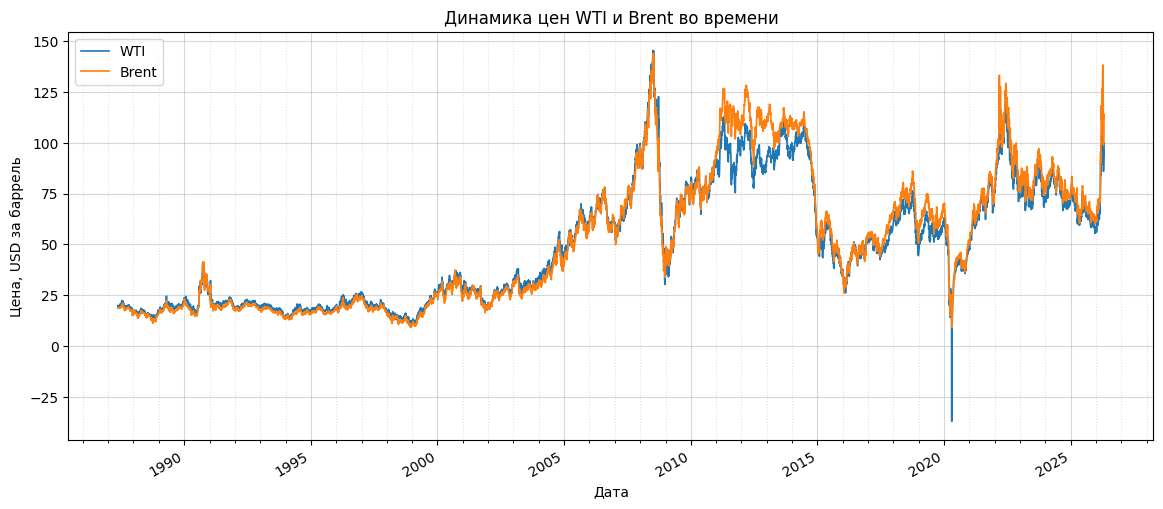

In [12]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["WTI"], label="WTI", linewidth=1.2)
ax.plot(df.index, df["Brent"], label="Brent", linewidth=1.2)

ax.set_title("Динамика цен WTI и Brent во времени")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена, USD за баррель")

# major ticks: каждые 5 лет, с подписями
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# minor ticks: каждый год, без подписей
ax.xaxis.set_minor_locator(mdates.YearLocator(1))

# сетка
ax.grid(True, which="major", linestyle="-", alpha=0.5)
ax.grid(True, which="minor", linestyle=":", alpha=0.35)

ax.legend()
fig.autofmt_xdate()
plt.show()

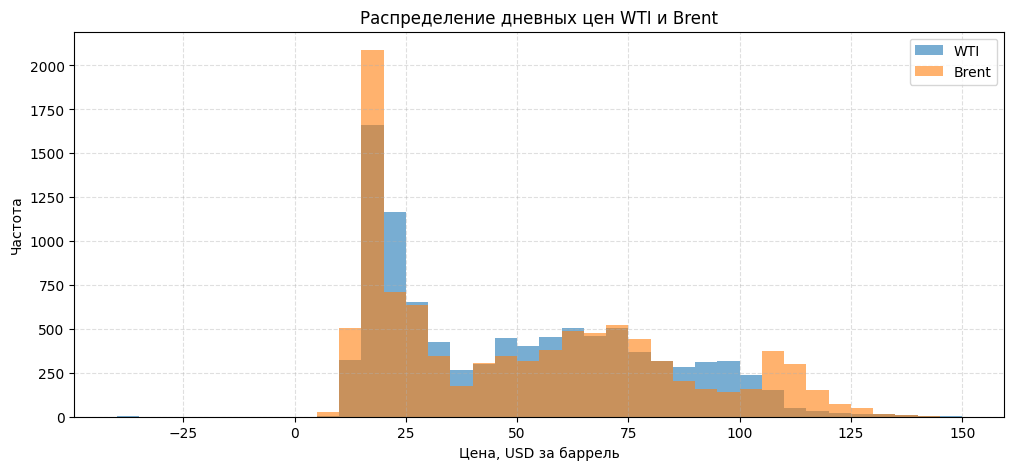

In [13]:
bins = range(-40, 155, 5)

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df["WTI"].dropna(), bins=bins, alpha=0.6, label="WTI")
ax.hist(df["Brent"].dropna(), bins=bins, alpha=0.6, label="Brent")

ax.set_title("Распределение дневных цен WTI и Brent")
ax.set_xlabel("Цена, USD за баррель")
ax.set_ylabel("Частота")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.show()

По графикам видно, что WTI и Brent ведут себя очень похоже: ряды практически совпадают по форме, крупные всплески и падения приходятся на одни и те же периоды (2008–2009 гг., 2014–2016 гг., 2020 г. и недавние всплески после 2022 г.). На гистограмме основная масса наблюдений для обоих эталонов сосредоточена примерно в диапазоне 20–80 долларов за баррель (высоченный пик 20–25 означает, что особенно много дней цена была именно в этом узком коридоре, это отражает длительный ранний период истории, когда нефть торговалась относительно дёшево и стабильно), при этом у Brent распределение слегка сдвинуто вправо, что отражает его более высокий средний уровень цен по сравнению с WTI. В правом хвосте гистограммы видны редкие, но существенные эпизоды очень высоких цен (выше 100–120 долларов), а в левом хвосте для WTI выделяется аномальный участок с отрицательными значениями, соответствующий кратковременному обвалу цен в период COVID‑кризиса.

### 5.5. Инженерные признаки

In [14]:
# абсолютное изменение цены
df["WTI_diff"] = df["WTI"].diff()

# дневная доходность
df["WTI_ret"] = df["WTI"].pct_change()

# скользящее среднее (7 дней)
df["WTI_rolling_mean_7"] = df["WTI"].rolling(7).mean()

# скользящая волатильность (стд дневной доходности за 30 дней)
df["WTI_volatility_30"] = df["WTI_ret"].rolling(30).std()

# лаговые признаки
df["WTI_lag_1"] = df["WTI"].shift(1)
df["WTI_lag_7"] = df["WTI"].shift(7)

# базовые признаки для Brent
df["Brent_diff"] = df["Brent"].diff()
df["Brent_ret"] = df["Brent"].pct_change()

In [15]:
# пример: смотрим данные за пару недель
sample = df.loc["2005-01-10":"2005-01-25", 
                ["WTI", "WTI_diff", "WTI_ret", 
                 "WTI_rolling_mean_7", "WTI_volatility_30",
                 "WTI_lag_1", "WTI_lag_7",
                 "Brent", "Brent_diff", "Brent_ret"]]

display(sample)

,WTI,WTI_diff,WTI_ret,WTI_rolling_mean_7,WTI_volatility_30,WTI_lag_1,WTI_lag_7,Brent,Brent_diff,Brent_ret
Date,,,,,,,,,,
2005-01-10,45.31,-0.01,-0.000221,44.365714,0.030258,45.32,41.78,44.71,1.43,0.033041
2005-01-11,45.66,0.35,0.007725,44.647143,0.030281,45.31,43.69,43.45,-1.26,-0.028182
2005-01-12,46.46,0.80,0.017521,45.090000,0.030433,45.66,43.36,43.75,0.30,0.006904
2005-01-13,48.11,1.65,0.035514,45.682857,0.031092,46.46,43.96,45.76,2.01,0.045943
2005-01-14,48.41,0.30,0.006236,46.397143,0.031052,48.11,43.41,45.26,-0.50,-0.010927
2005-01-18,48.46,0.05,0.001033,46.818571,0.027807,48.41,45.51,45.18,-0.08,-0.001768
2005-01-19,47.61,-0.85,-0.017540,47.145714,0.026329,48.46,45.32,45.16,-0.02,-0.000443
2005-01-20,47.01,-0.60,-0.012602,47.388571,0.026215,47.61,45.31,44.06,-1.10,-0.024358
2005-01-21,48.31,1.30,0.027654,47.767143,0.026562,47.01,45.66,45.88,1.82,0.041307


#### Очень короткое объяснение по каждой группе 
* WTI_diff — абсолютное дневное изменение цены: показывает, на сколько долларов за день выросла или упала нефть, удобно для оценки масштаба движений.
* WTI_ret — относительное изменение (pct_change), то есть дневная доходность в долях; этот признак нормирует изменения и позволяет сравнивать периоды и сопоставлять WTI с Brent по процентам, а не по долларам.
* Скользящее среднее WTI_rolling_mean_7 сглаживает краткосрочный шум и отражает локальный уровень цен за неделю, а WTI_volatility_30 — стандартное отклонение дневных доходностей на окне 30 дней, которое используется как простая мера текущей волатильности рынка.
* Лаги WTI_lag_1 и WTI_lag_7 сохраняют значения цены 1 и 7 дней назад; они нужны для анализа зависимости текущей цены от прошлых уровней и для возможных простых моделей, основанных на прошлых значениях ряда. Аналогичные признаки Brent_diff и Brent_ret строятся для Brent, чтобы затем напрямую сравнивать изменения и доходности двух эталонов.



### 5.6. NumPy-вычисления

In [16]:
# перевод ряда WTI в NumPy-массив
arr = df["WTI"].dropna().to_numpy()

# среднее значение;
mean_val = np.mean(arr)

# стандартное отклонение
std_val = np.std(arr)

# медиана;
median_val = np.median(arr)

# квантили;
q25 = np.quantile(arr, 0.25)
q75 = np.quantile(arr, 0.75)

# градиент;
grad = np.gradient(arr)

print("mean   =", mean_val)
print("std    =", std_val)
print("median =", median_val)
print("q25    =", q25)
print("q75    =", q75)

mean   = 49.455937757625726
std    = 29.323057643600368
median = 45.72
q25    = 20.9575
q75    = 71.96


In [17]:
# простая линейная аппроксимация тренда WTI на всём периоде
x = np.arange(len(arr))           # условная ось времени: 0, 1, 2, ...
slope, intercept = np.polyfit(x, arr, 1)

print("slope      =", slope)
print("intercept  =", intercept)

slope      = 0.007531603969614352
intercept  = 12.916361099041698


Пояснительная бригада переводит ряд цен WTI в обычный NumPy‑массив и считает по нему несколько простых чисел. Среднее и медиана показывают, вокруг каких уровней в целом крутились цены, а стандартное отклонение и квартили — насколько сильно они разъезжались вверх‑вниз. Градиент даёт представление о том, насколько быстро менялась цена от дня к дню: большие по модулю значения соответствуют дням с самыми резкими движениями.

### 5.7. Анализ временного ряда

In [18]:
# 5.7.1 Построить **скользящее среднее**.
# уже посчитали в 5.5 df["WTI_rolling_mean_7"] = df["WTI"].rolling(7).mean()

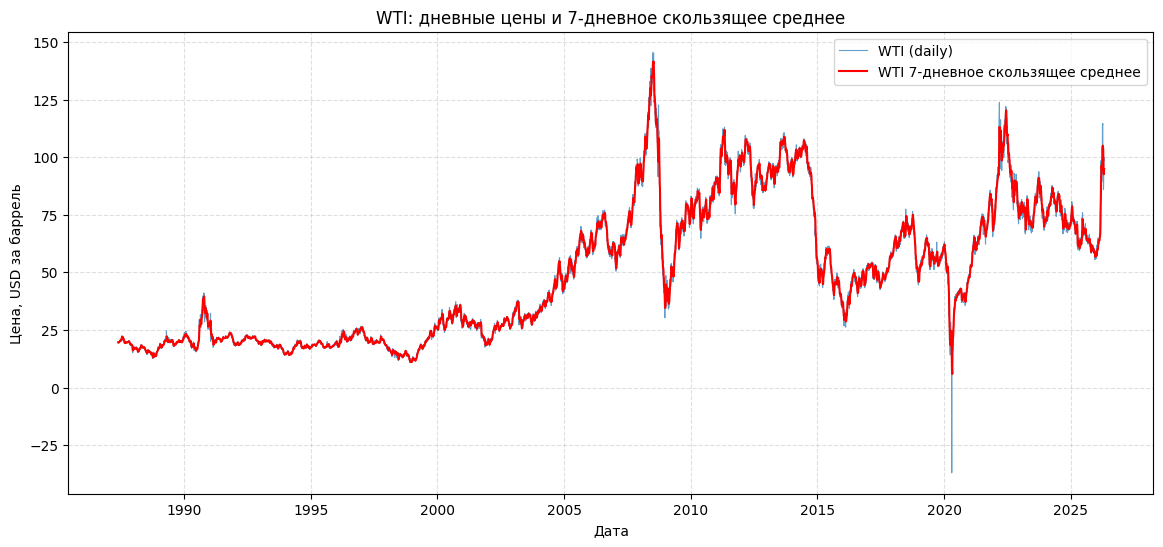

In [19]:
# 5.7.1 График дневных цен и скользящего среднего

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["WTI"], label="WTI (daily)", linewidth=0.8, alpha=0.7)
ax.plot(df.index, df["WTI_rolling_mean_7"], 
        label="WTI 7-дневное скользящее среднее", linewidth=1.5, color="red")

ax.set_title("WTI: дневные цены и 7-дневное скользящее среднее")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена, USD за баррель")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

In [20]:
# 5.7.2 ыполнить **ресемплинг по месяцам**.
# месячные средние цен WTI и Brent
monthly = df[["WTI", "Brent"]].resample("ME").mean()

display(monthly.head())

,WTI,Brent
Date,,
1987-05-31,19.535714,18.577143
1987-06-30,20.073333,18.860476
1987-07-31,21.342174,19.856522
1987-08-31,20.310952,18.979524
1987-09-30,19.530000,18.313182


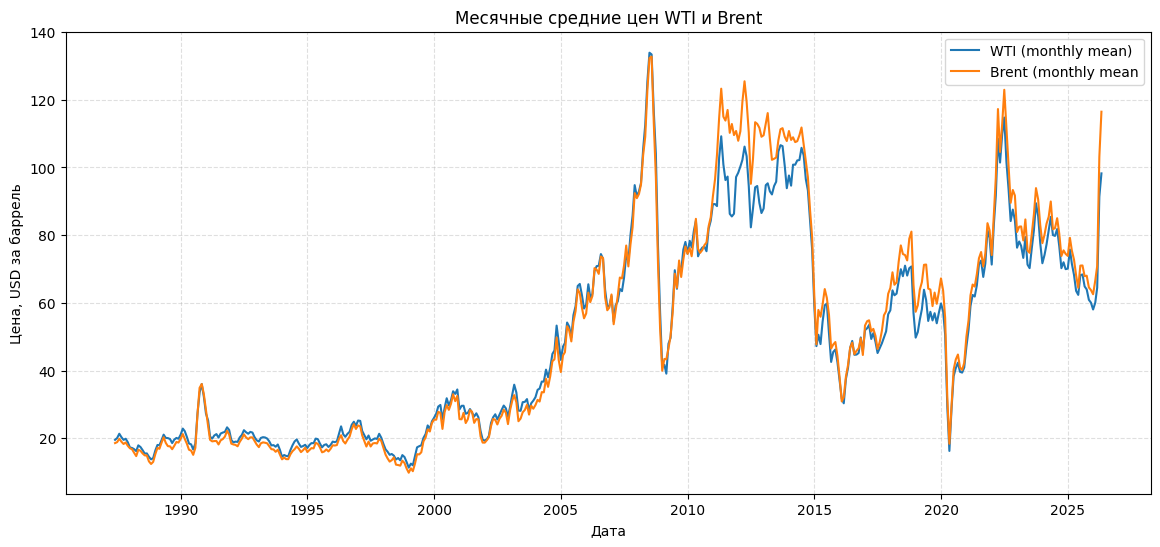

In [21]:
# 5.7.2 график месячных средних

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly.index, monthly["WTI"], label="WTI (monthly mean)")
ax.plot(monthly.index, monthly["Brent"], label="Brent (monthly mean")

ax.set_title("Месячные средние цен WTI и Brent")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена, USD за баррель")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

5.7.3. Исследовать **изменения цены во времени**.
Этому служат сразу два уровня:
*дневной график WTI + скользящее среднее (5.7.1) — видно, когда цена растёт, падает, стоит на месте, а также как быстро происходят эти изменения;
*график месячных средних WTI и Brent (5.7.2) — показывает крупные циклы: периоды дешёвой нефти, подъёмы до 100+, падения в кризисы.
Краткий смысл: на дневном графике видны локальные движения и шум, на месячном — большие волны и режимы рынка (рост, плато, спад).

5.7.4. Оценить **волатильность**.
Признак волатильности мы посчитали в 5.5:

df["WTI_volatility_30"] = df["WTI_ret"].rolling(30).std().

Это стандартное отклонение дневных доходностей на окне в 30 дней — простая скользящая оценка текущей «раздерганности» рынка.

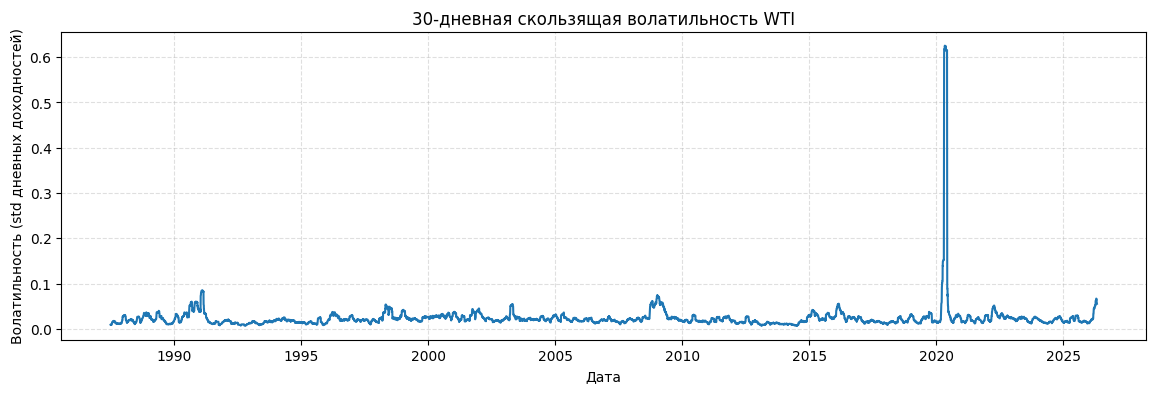

In [22]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df["WTI_volatility_30"])
ax.set_title("30-дневная скользящая волатильность WTI")
ax.set_xlabel("Дата")
ax.set_ylabel("Волатильность (std дневных доходностей)")
ax.grid(True, linestyle="--", alpha=0.4)
plt.show()

 По этому графику видно, в какие моменты волатильность «взрывается» (кризисы) и где она низкая (спокойные периоды).

5.7.5. Сделать вывод, где ряд выглядит стабильным, а где — нет.
По графику цен и 7‑дневного скользящего среднего WTI видно, что до начала 2000‑х ряд ведёт себя относительно стабильно: колебания невелики, скользящее среднее движется плавно, без резких наклонов. Начиная с середины 2000‑х появляются участки сильных трендов и больших колебаний, особенно вокруг кризиса 2008–2009 гг., падения цен в 2014–2016 гг. и эпизода 2020 г.; на эти же периоды приходится всплеск 30‑дневной волатильности, что указывает на высокую нестабильность ряда. Между крупными кризисами, когда волатильность снижается и скользящее среднее идёт почти горизонтально, можно говорить о более спокойных режимах рынка.
**Аномальный провал WTI весной 2020 года связан с пандемией COVID‑19: резким падением спроса, переполнением хранилищ и тем, что фьючерсы WTI в апреле 2020 впервые в истории ушли в отрицательные значения.**

#### Дополнительно для магистерского уровня

In [23]:
def rolling_slope(series, window=30):
    slopes = [np.nan] * len(series)
    y = series.to_numpy()

    for i in range(window - 1, len(series)):
        y_window = y[i - window + 1:i + 1]
        x_window = np.arange(window)

        if np.isnan(y_window).any():
            continue

        slope = np.polyfit(x_window, y_window, 1)[0]
        slopes[i] = slope

    return pd.Series(slopes, index=series.index)

# локальный тренд WTI на окне 30 дней
df["WTI_trend_30"] = rolling_slope(df["WTI"], window=30)

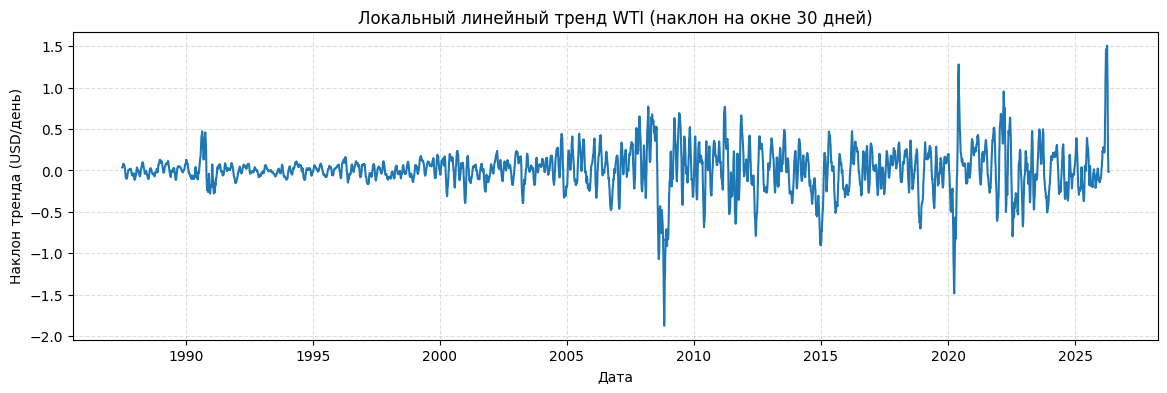

In [24]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df["WTI_trend_30"])
ax.set_title("Локальный линейный тренд WTI (наклон на окне 30 дней)")
ax.set_xlabel("Дата")
ax.set_ylabel("Наклон тренда (USD/день)")
ax.grid(True, linestyle="--", alpha=0.4)
plt.show()

Чтобы не смотреть на цены «на глазок», я посчитал локальный тренд WTI на окне 30 дней. Для каждого дня беру последние 30 значений, через них провожу прямую (np.polyfit) и забираю её наклон в признак WTI_trend_30. Если наклон положительный — на этом участке рынок скорее ползёт вверх, если отрицательный — тенденция вниз, если около нуля — болтаемся в боковике. По сути это способ честно ответить на вопрос «мы сейчас растём или мне просто кажется, потому что последние пару дней повезло?».

### 5.8. Сравнение WTI и Brent

In [37]:
# 5.8.1 Сравнить уровни цен WTI и Brent
df[["WTI", "Brent"]].describe()

,WTI,Brent
count,9704.000000,9704.000000
mean,49.455938,51.137665
std,29.324569,32.778523
min,-36.980000,9.100000
25%,20.957500,19.500000
50%,45.720000,46.010000
75%,71.960000,74.782500
max,145.310000,143.950000


In [38]:
# 5.8.2 Посчитать корреляцию между ценами
price_corr = df["WTI"].corr(df["Brent"])

price_corr

np.float64(0.9910584364652559)

In [39]:
# 5.8.3 Посчитать корреляцию между дневными доходностями
ret_corr = df["WTI_ret"].corr(df["Brent_ret"])

ret_corr

np.float64(0.4789630203458596)

### 5.8.4 Вывод
В целом ряды WTI и Brent очень похожи: они проходят через одни и те же крупные пики и провалы, а Brent почти всегда чуть дороже, что видно и по средним уровням, и по графикам. Уровень корреляции цен 0.99 — эталоны живут в одном «ценовом мире», различаясь в основном постоянной надбавкой Brent к WTI. Корреляция дневных доходностей тоже высокая, то есть большинство шоков рынок отыгрывает синхронно, однако она ниже, чем корреляция уровней, поэтому краткосрочно возможны расхождения и игра на спреде между эталонами.

По описательным статистикам видно, что Brent в среднем дороже WTI: его средний уровень и медиана немного выше, чем у WTI. Минимумы и максимумы у рядов сопоставимы по порядку величины, но Brent чаще проводит время на более высоких ценовых уровнях, что соответствует его исторической премии к WTI: за международный эталон обычно платят немного дороже.

### 5.9. Поиск кризисных периодов